# Model comparison according to brain score

Imports

In [1]:
import pickle
import warnings
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import logging
import sys
sys.path.insert(1, '../')


# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

In [6]:
def calculate_brain_score_events(
        cv_results,
        test=True,
        crop=(-0.2, 1.58),
        sfreq=64,
        event="go", # go, stop, response_nostop, response_stop
        event_column = 'type'

):
    if test:
        variable = 'test'
    else:
        variable = 'train'

    person_results = {}
    for channel in cv_results.keys():
        # extract data from all splits
        channel_results = cv_results[channel]
        epochs_original_cvs = cv_results[channel][f'{variable}_original'].to_numpy()
        epochs_predicted_cvs = cv_results[channel][f'{variable}_predicted'].to_numpy()

        # calculate time window in timepoints
        t_min, t_max = crop

        t_min_tp = int(t_min*sfreq)
        t_max_tp = int(t_max*sfreq)

        logger.debug(f"t min in tp: {t_min_tp}\nt max in tp:{t_max_tp}")

        # iterate over cv repeats
        cv_pearsons_r = []
        cv_pearsons_r_inside = []
        for i, (original, predicted) in enumerate(zip(epochs_original_cvs, epochs_predicted_cvs)):
            original_slices = []
            predicted_slices = []
            # iterate over trials
            for trial_index, (trial_original, trial_predicted) in enumerate(zip(original, predicted)):
                trial_events = channel_results.iloc[i][f'{variable}_events'][trial_index]
                try:
                    event_tp = trial_events[trial_events[f'{event_column}'] == event]['latency'].to_numpy()[0]
                    logger.debug(f"Event {event} has latency: {event_tp}")

                    trial_original_slice = trial_original[event_tp+t_min_tp:event_tp+t_max_tp]
                    trial_predicted_slice = trial_predicted[event_tp+t_min_tp:event_tp+t_max_tp]
                    logger.debug(f"Trial slice length: {trial_original_slice.shape}")

                    original_slices.append(trial_original_slice)
                    predicted_slices.append(trial_predicted_slice)

                    r_inside = np.corrcoef(trial_original_slice.flatten(), trial_predicted_slice.flatten())[0, 1]
                    cv_pearsons_r_inside.append(r_inside)
                except IndexError:
                    logger.debug(f"Skipping trial {trial_index}: No matching event found.")

            r = np.corrcoef(np.array(original_slices).flatten(), np.array(predicted_slices).flatten())[0, 1]
            cv_pearsons_r.append(r)

        cv_pearsons_r = np.array(cv_pearsons_r)
        r_mean = cv_pearsons_r.mean()
        r_sd = cv_pearsons_r.std()

        person_results[channel] = {
            'cv_pearsons_r': cv_pearsons_r, 
            'cv_mean': r_mean, 
            'cv_std': r_sd,
            'cv_pearsons_r_inside': np.array(cv_pearsons_r_inside),
            'cv_mean_r_inside': np.array(cv_pearsons_r_inside).mean(),
        }

    return person_results

def extract_alphas(cv_results, model):
    """Extract alpha values for each channel from cross-validation results."""
    alpha_data = []
    for channel, results in cv_results.items():
        alphas = np.concatenate(results['alphas'].to_numpy()) if 'alphas' in results else np.array([])
        for alpha in alphas:
            alpha_data.append({
                'Channel': channel,
                'Model': model,
                'Alpha': alpha
            })
    return alpha_data

def load_results(file_name, model, results_main_path, events_to_test):
    """Load cross-validation results and compute Pearson's r for each event, including alpha values."""
    data_rows = []
    alpha_rows = []

    # Load CV results once
    with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
        cv_results = pickle.load(handle)

    # Extract alpha values
    alpha_rows.extend(extract_alphas(cv_results, model))

    # Compute Pearson's r for each event
    for event, (time_window, event_column) in events_to_test.items():
        for dataset, is_test in zip(['train', 'test'], [False, True]):
            pearsons_r_results = calculate_brain_score_events(cv_results, test=is_test, crop=time_window, event=event, event_column=event_column)
            for channel, results in pearsons_r_results.items():
                logger.debug(f"Number of events in CV score: {len(results['cv_pearsons_r_inside'])}")
                data_rows.append({
                    'Model': model,
                    'Dataset': dataset,
                    'Channel': channel,
                    'Pearson\'s r': results['cv_mean'],
                    'Event': event
                })

    return data_rows, alpha_rows

def aggregate_results(current_file_names, unfold_models, results_main_path, events_to_test):
    """Aggregate Pearson's r and alpha values across all files and models."""
    all_data = []
    all_alphas = []

    for file_name in current_file_names:
        for model in unfold_models:
            results, alphas = load_results(file_name, model, results_main_path, events_to_test)
            all_data.extend(results)
            all_alphas.extend(alphas)

    return pd.DataFrame(all_data), pd.DataFrame(all_alphas)

def plot_violin(df, event, channel, means):
    """Generate a violin plot for a specific event and channel."""
    df_event = df[df['Event'] == event]

    plt.figure(figsize=(16, 6))
    ax = sns.violinplot(x='Model', y='Pearson\'s r', hue='Dataset', data=df_event, palette='colorblind', split=True)

    # Add mean value annotations
    for i, model in enumerate(df_event['Model'].unique()):
        for dataset, offset, color in zip(['train', 'test'], [-0.2, 0.2], ['blue', 'red']):
            mean_value = means[(means['Model'] == model) & (means['Dataset'] == dataset) & (means['Event'] == event)]['Pearson\'s r'].values
            if len(mean_value) > 0:
                ax.text(i + offset, mean_value[0], f"{mean_value[0]:.3f}", color=color, ha="center", va="bottom", fontsize=15)

    plt.title(f"Violin plot of Pearson's r for channel {channel} - Event: {event}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def process_and_plot_results(current_file_names, results_main_path, unfold_models, events_to_test, channel="Fz"):
    """Main function to process data and generate violin plots per event."""

    # Aggregate results
    df, df_alphas = aggregate_results(current_file_names, unfold_models, results_main_path, events_to_test)

    # Filter by channel
    df_channel = df[df['Channel'] == channel]

    # Compute mean values for annotation
    means = df_channel.groupby(['Model', 'Dataset', 'Event'])['Pearson\'s r'].mean().reset_index()

    # Plot for each event
    for event in df_channel['Event'].unique():
        plot_violin(df_channel, event, channel, means)

    plot_alphas(df_alphas, channel)

def plot_alphas(df_alphas, channel):
    """Plot alpha value distributions separately for each model."""
    models = df_alphas['Model'].unique()

    for model in models:
        df_model = df_alphas[(df_alphas['Channel'] == channel) & (df_alphas['Model'] == model)]

        plt.figure(figsize=(10, 4))
        sns.histplot(df_model['Alpha'], bins=20, color='royalblue')
        plt.xlabel('Alpha Values')
        plt.ylabel('Frequency')
        plt.title(f'Alpha Value Distribution for Model {model} - Channel {channel}')
        plt.grid(True)
        plt.show()

## Read data

In [7]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


### Check overfitting

Parameters

In [8]:
current_file_names = file_names[:9]
print(current_file_names)

results_main_path = '../data/cv_simple_ridge_alpha_10-10_cv_5-2'

unfold_models = [
    'baseline',
    'go', 
    'stop', 
    'response_main', 
    'response', 
    'full_stop_type', 
    'full_stop_type_stop_ssd', 
    'full_stop_type_ssd',
    'full_stop_type_sri', 
    'full_interactions'
]


['AB0407_SST14_EOG4', 'AB2407_SST14_new_EOG4', 'AD1406_SST14_EOG4', 'AF0905_SST14_EOG4', 'AK0102_SST14_EOG4', 'AR1607_SST14_EOG4', 'AT2303_SST14_EOG4', 'BP1901_SST14_new_EOG4', 'BS0511_SST14_EOG4']


## Look into results

In [123]:
# events_to_test = {
#     'baseline': (-0.2, 1.5),
#     'go': (-0.1, 0.3),
#     'stop': (-0.1, 0.3),
#     'response_stop': (-0.1, 0.1),
#     'response_nostop': (-0.1, 0.1)
# }
# 
# brain_score_results_df, alpha_results = aggregate_results(current_file_names, unfold_models, results_main_path, events_to_test)
# 
# plot_alphas(alpha_results, channel='Fz')

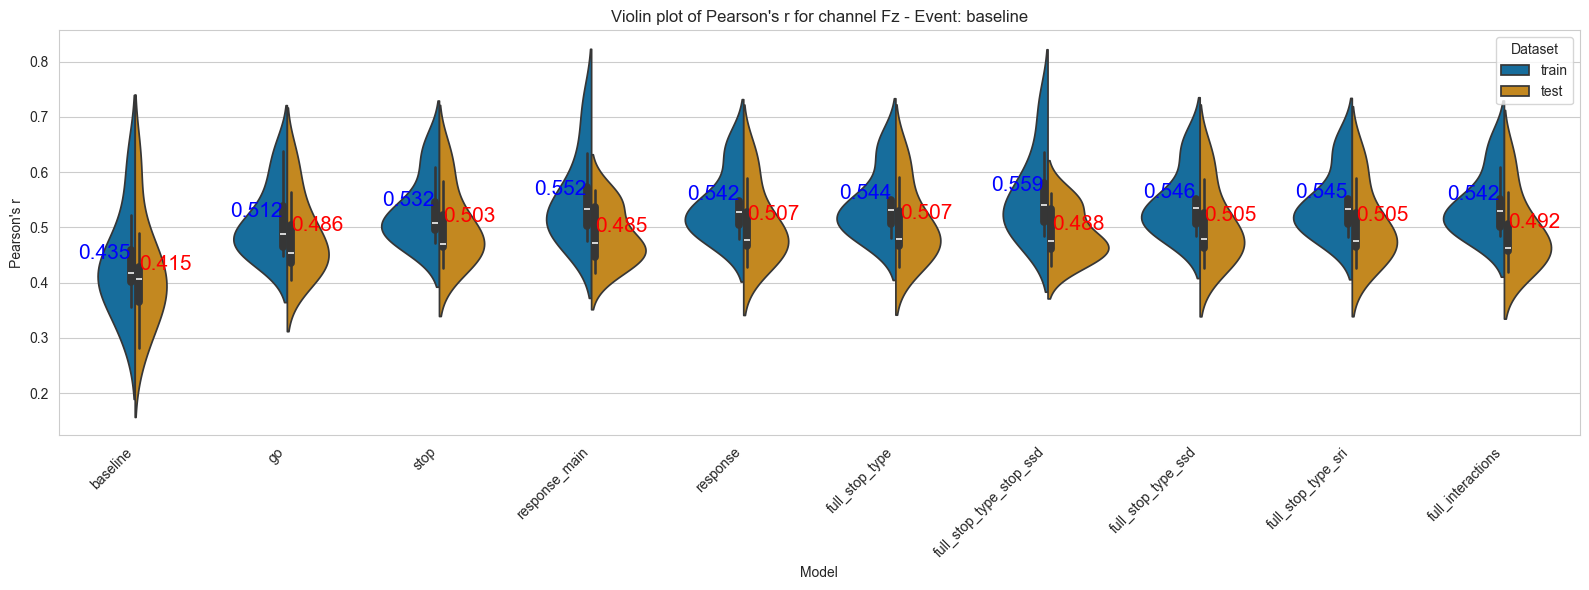

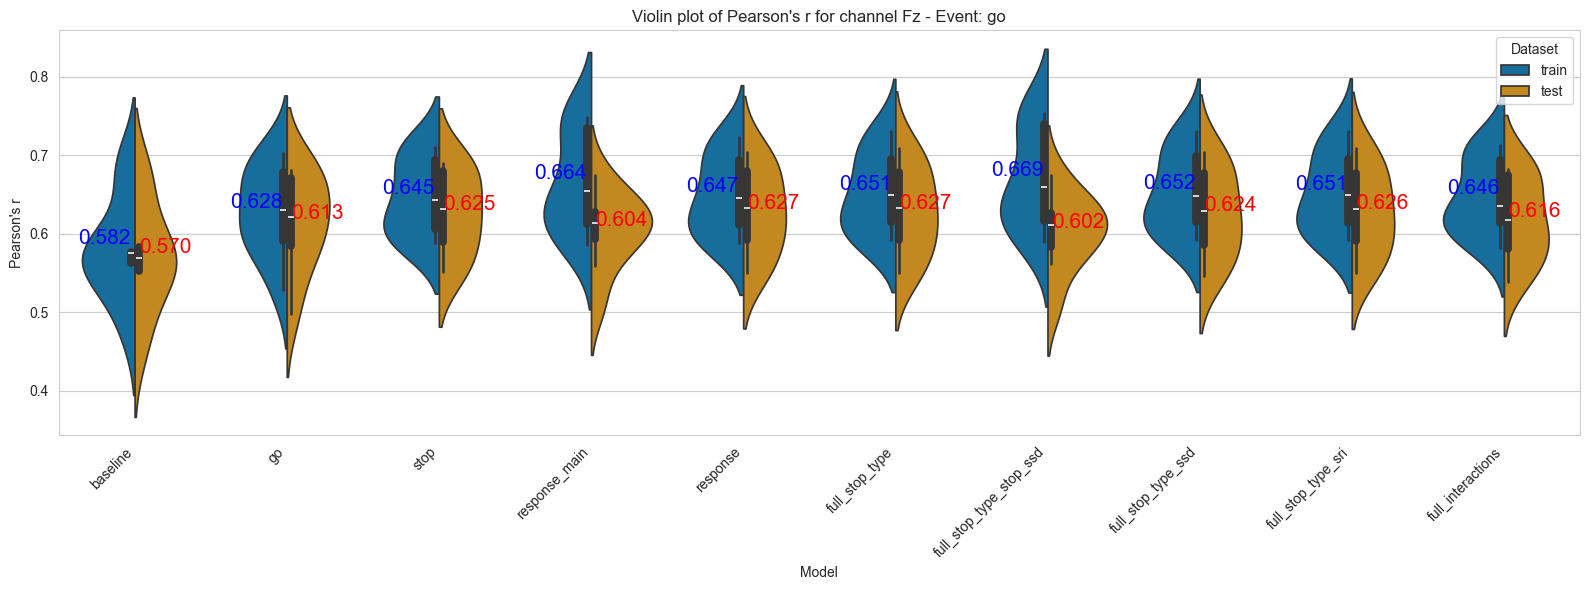

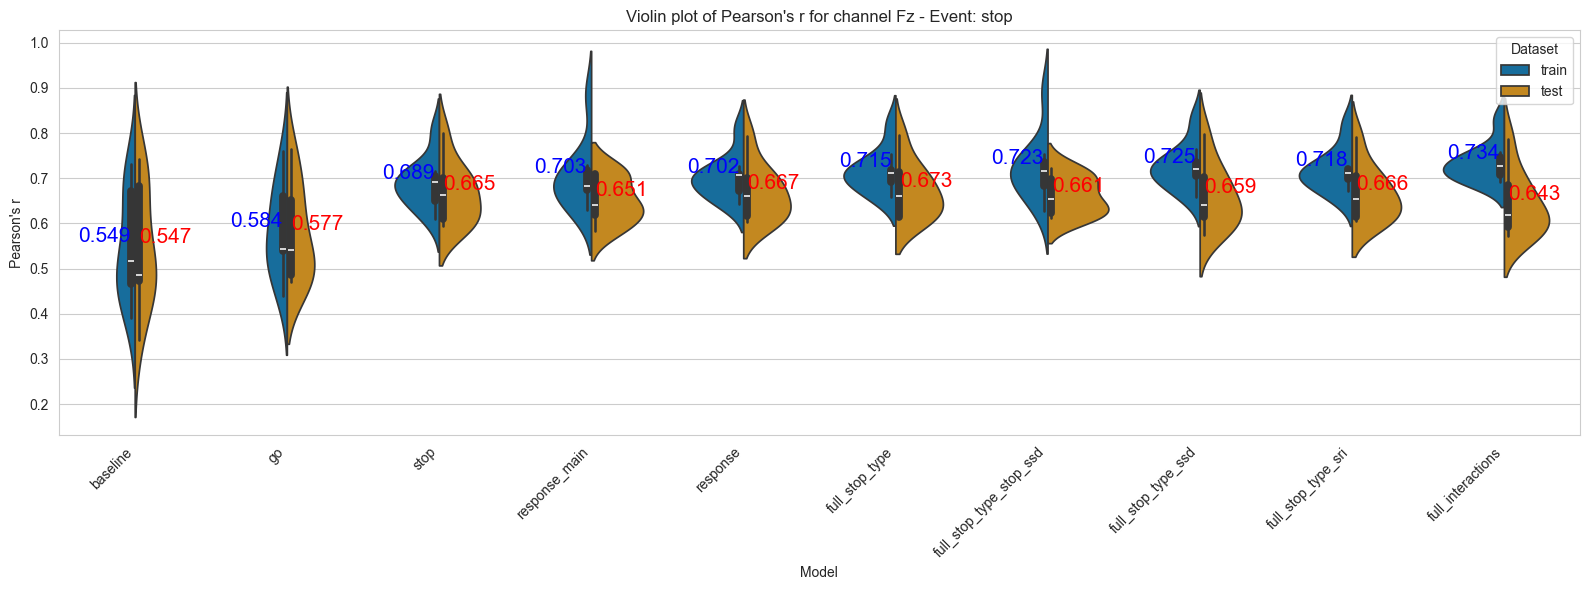

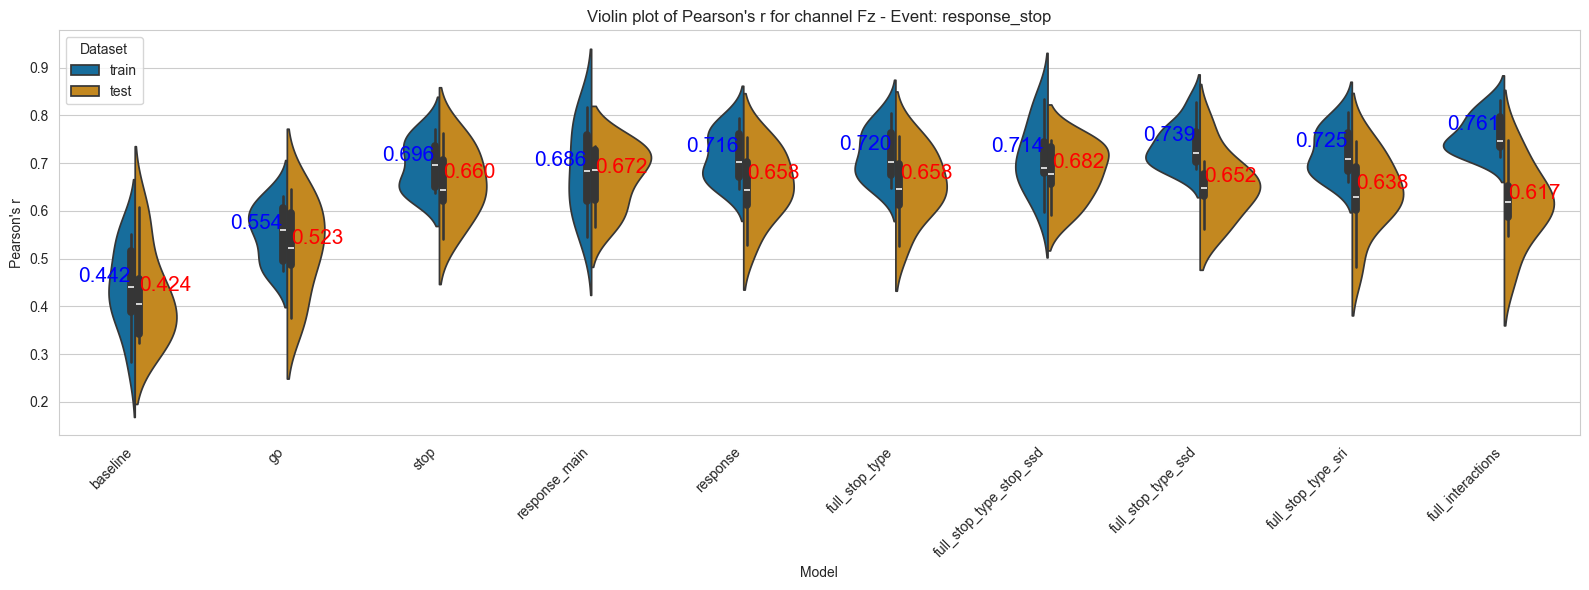

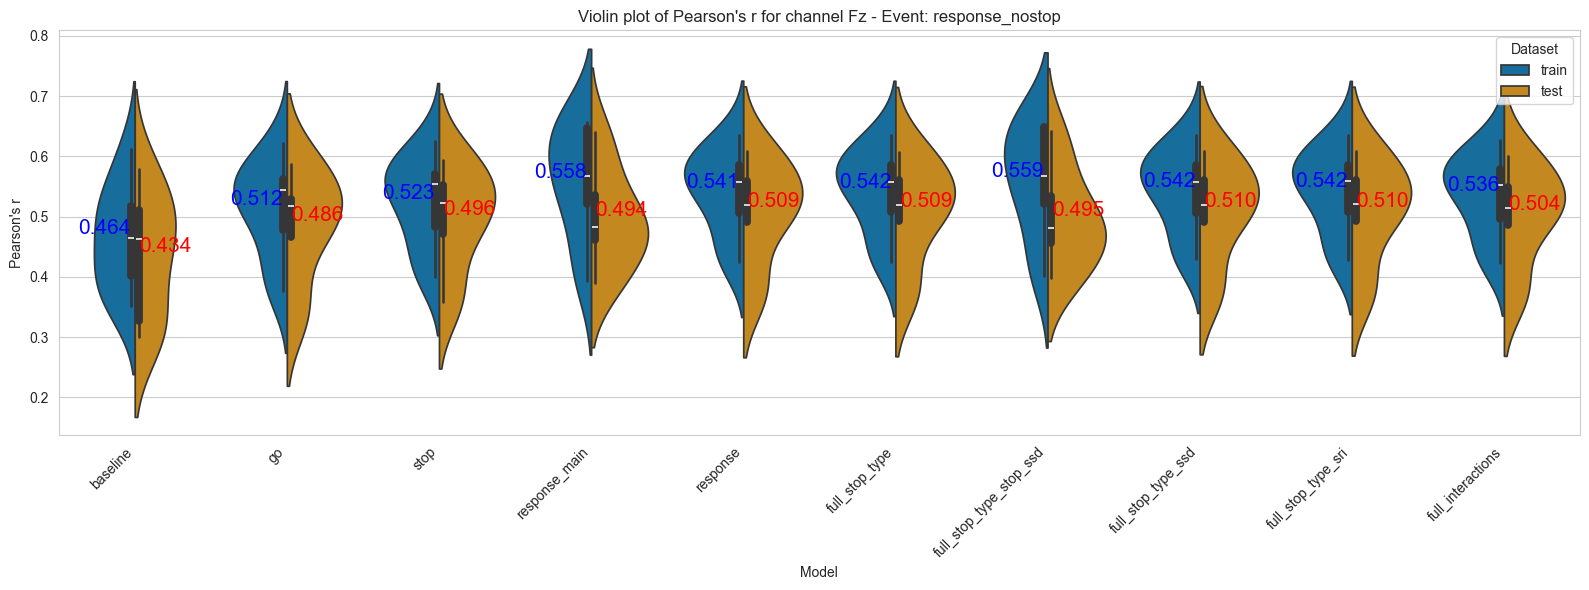

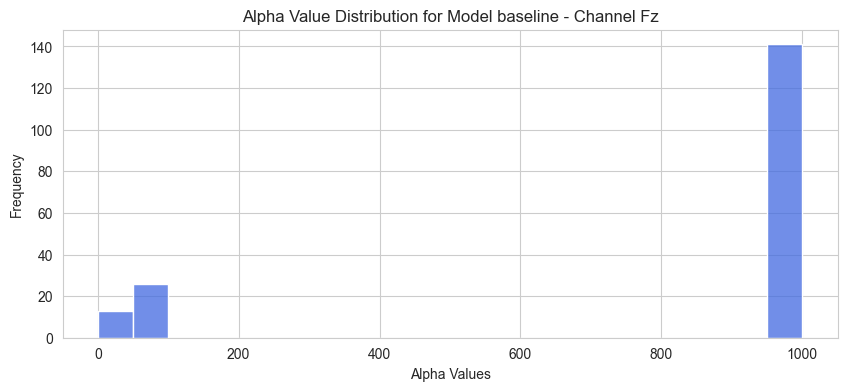

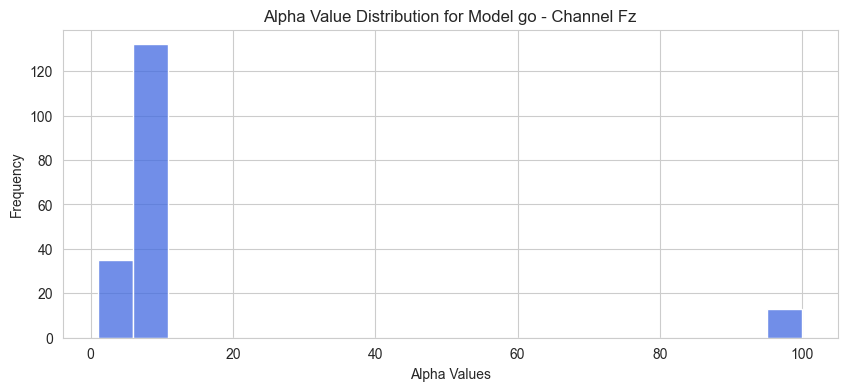

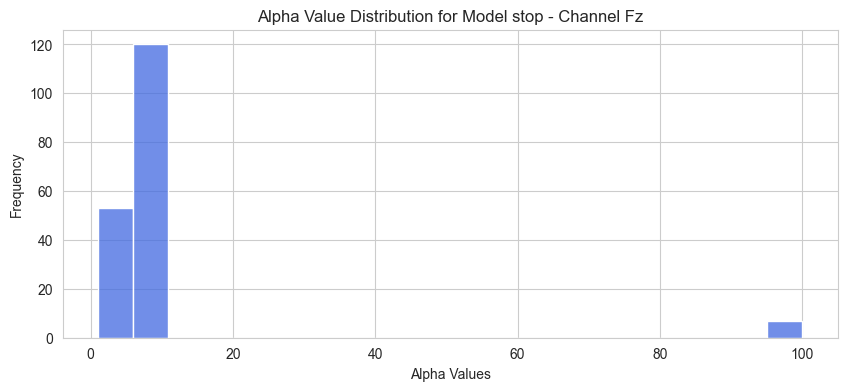

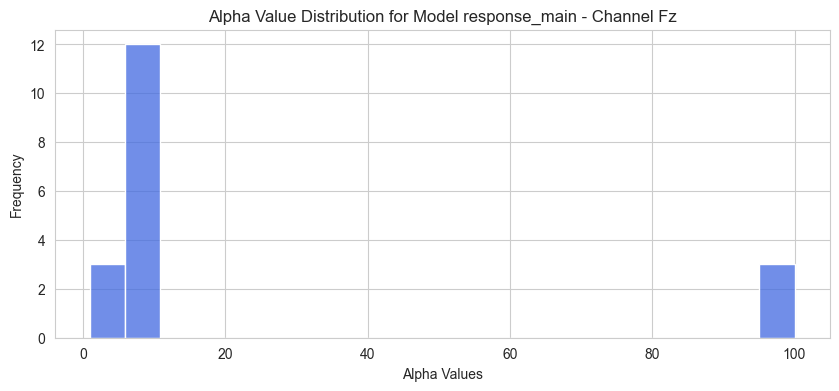

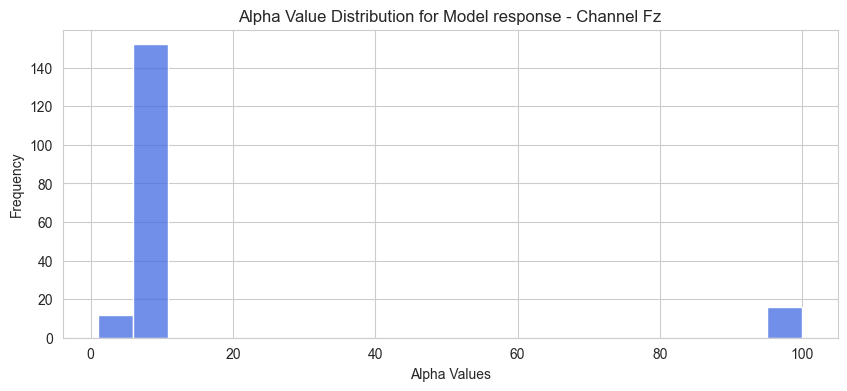

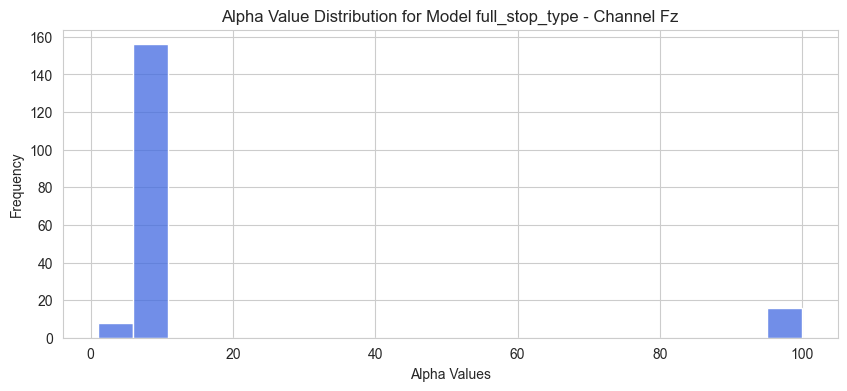

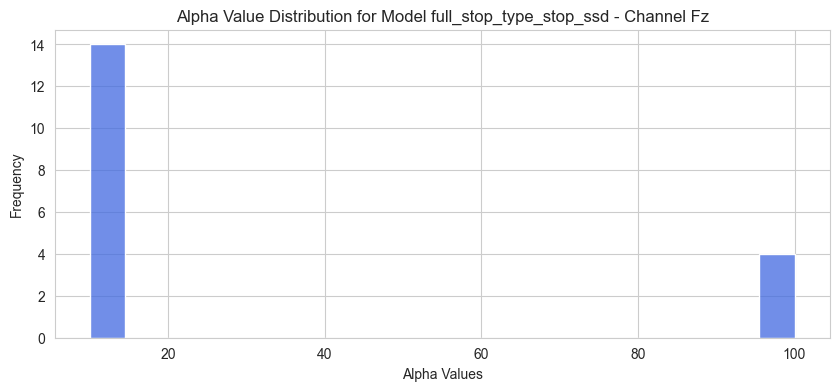

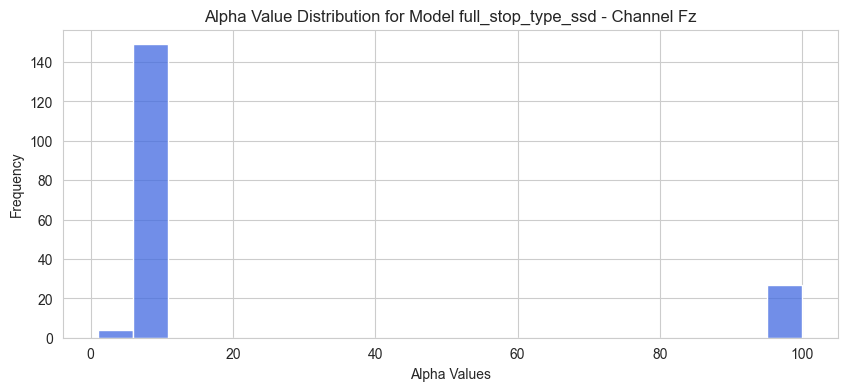

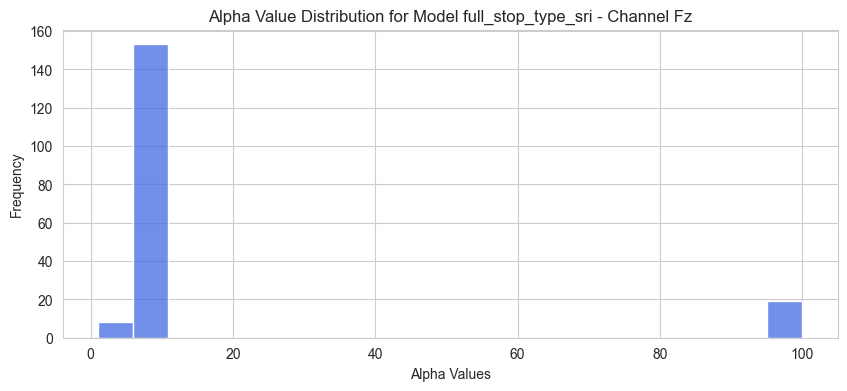

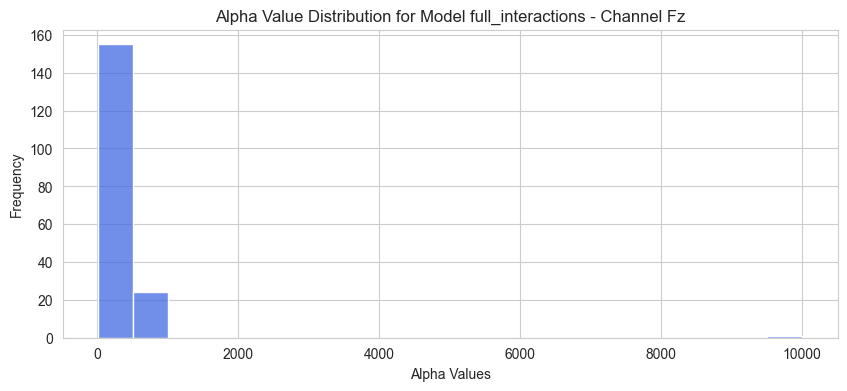

In [10]:
events_to_test = {
    'baseline': ((-0.2, 1.5), 'type'),
    'go': ((-0.1, 0.3), 'type'),
    'stop': ((-0.1, 0.3), 'type'),
    'response_stop': ((-0.1, 0.3), 'type'),
    'response_nostop': ((-0.1, 0.3), 'type')
}

process_and_plot_results(
    current_file_names=current_file_names,
    results_main_path=results_main_path,
    unfold_models=unfold_models,
    events_to_test=events_to_test,
    channel="Fz"
)

#### Results by dataset

Test

In [9]:
results_main_path = '../data/cv_simple_ridge_alpha_10-10_test'

unfold_models = [
    # 'baseline', 
    #              'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
    #              'full_stop_type_sri', 
    'full_interactions'
                 ]
time_window = (-0.2, 1.5)

models_results_aggregation = []
for file_name in current_file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score_events(
                cv_results,
                test=True,
                crop=time_window
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

<Figure size 640x480 with 0 Axes>

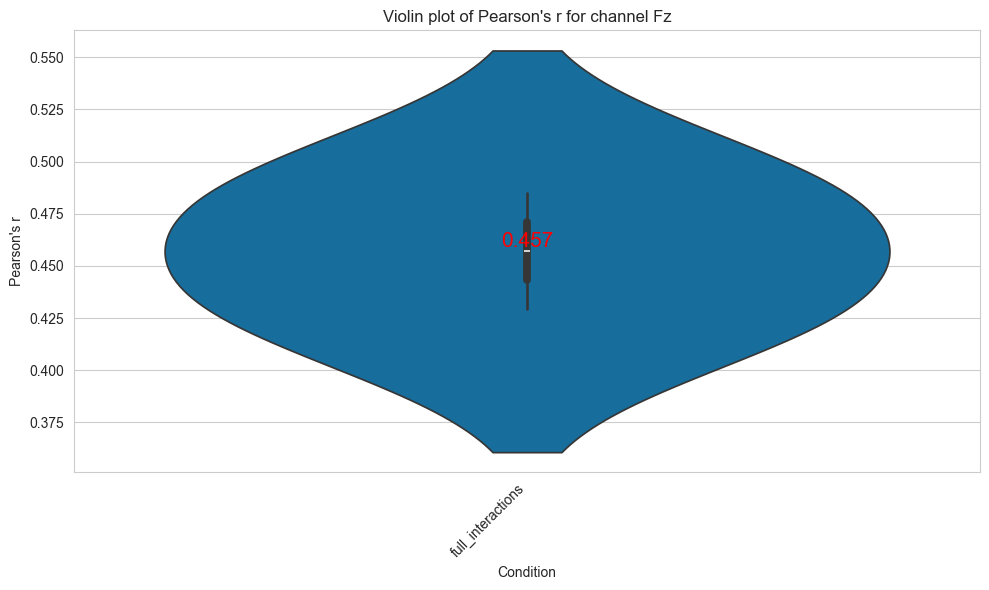

In [10]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    # for model_name, pearsons_r_results in person_results.items():
    #     data = pearsons_r_results[channel]['cv_pearsons_r']
    #     sns.violinplot(data, label=f"{model_name}: {np.mean(data):.3f}")
    # 
    # plt.legend()
    # Prepare the data for the DataFrame
    # Prepare the data for the DataFrame
    rows = []
    means = []
    for key, value in person_results.items():
        cv_values = value[channel]['cv_pearsons_r']
        rows.extend({'Condition': key, 'Pearson\'s r': val} for val in cv_values)
        means.append((key, sum(cv_values) / len(cv_values)))

    # Create DataFrame
    df = pd.DataFrame(rows)

    # Plot using seaborn
    plt.figure(figsize=(10, 6))
    ax = sns.violinplot(x='Condition', y='Pearson\'s r', data=df, palette='colorblind')

    # Annotate with means
    for i, (condition, mean) in enumerate(means):
        ax.text(i, mean, f"{mean:.3f}", color="red", ha="center", va="bottom", fontsize=15)

    # Plot aesthetics
    plt.title(f"Violin plot of Pearson's r for channel {channel}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Plot results - within people aggregations

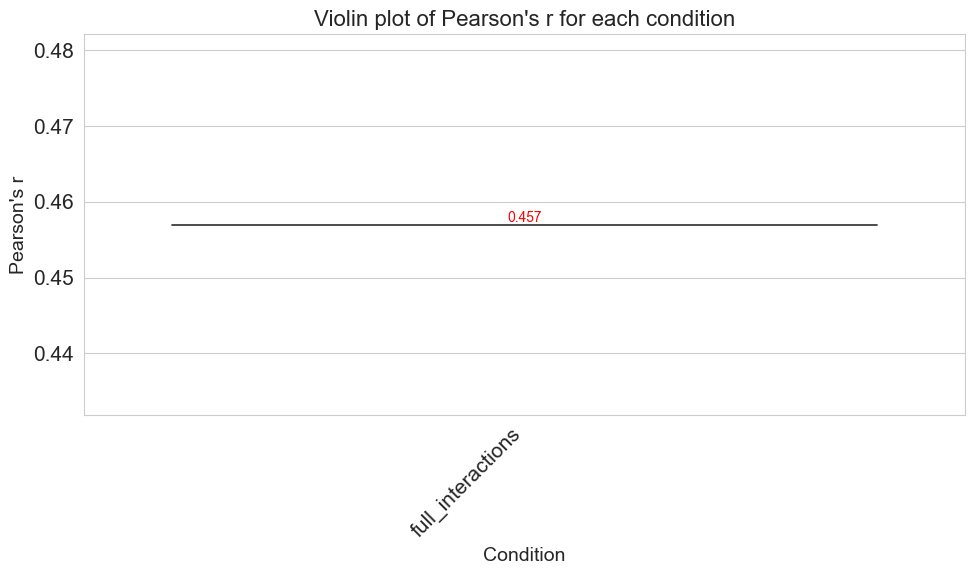

In [39]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Prepare the data for the DataFrame
rows = []
means = {}
for condition, values in person_model_agg.items():
    rows.extend({'Condition': condition, 'Pearson\'s r': val} for val in values)
    means[condition] = sum(values) / len(values)  # Calculate means for annotations

# Create DataFrame
df = pd.DataFrame(rows)

# Plot using seaborn
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='Condition', y='Pearson\'s r', data=df, palette='colorblind')

# Annotate means
for i, condition in enumerate(means):
    mean_value = means[condition]
    ax.text(i, mean_value, f"{mean_value:.3f}", color="red", ha="center", va="bottom", fontsize=10)

# Plot aesthetics
plt.title("Violin plot of Pearson's r for each condition")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Train

In [40]:
results_main_path = '../data/cv_simple_ridge_alpha_10-10_test'

unfold_models = [
    # 'baseline', 
    #              'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
    #              'full_stop_type_sri', 
    'full_interactions'
                 ]

models_results_aggregation = []
for file_name in current_file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score_events(
                cv_results,
                test=False,
                crop=time_window
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

2025-01-29 16:22:45,589 - __main__ - DEBUG - t min in tp: -12
t max in tp:96
2025-01-29 16:22:45,591 - __main__ - DEBUG - Event go has latency: 13
2025-01-29 16:22:45,592 - __main__ - DEBUG - Trial slice length: (108,)
2025-01-29 16:22:45,593 - __main__ - DEBUG - Event go has latency: 13
2025-01-29 16:22:45,594 - __main__ - DEBUG - Trial slice length: (108,)
2025-01-29 16:22:45,595 - __main__ - DEBUG - Event go has latency: 13
2025-01-29 16:22:45,595 - __main__ - DEBUG - Trial slice length: (108,)
2025-01-29 16:22:45,596 - __main__ - DEBUG - Event go has latency: 13
2025-01-29 16:22:45,596 - __main__ - DEBUG - Trial slice length: (108,)
2025-01-29 16:22:45,598 - __main__ - DEBUG - Event go has latency: 13
2025-01-29 16:22:45,598 - __main__ - DEBUG - Trial slice length: (108,)
2025-01-29 16:22:45,599 - __main__ - DEBUG - Event go has latency: 13
2025-01-29 16:22:45,600 - __main__ - DEBUG - Trial slice length: (108,)
2025-01-29 16:22:45,602 - __main__ - DEBUG - Event go has latency: 13
2

<Figure size 640x480 with 0 Axes>

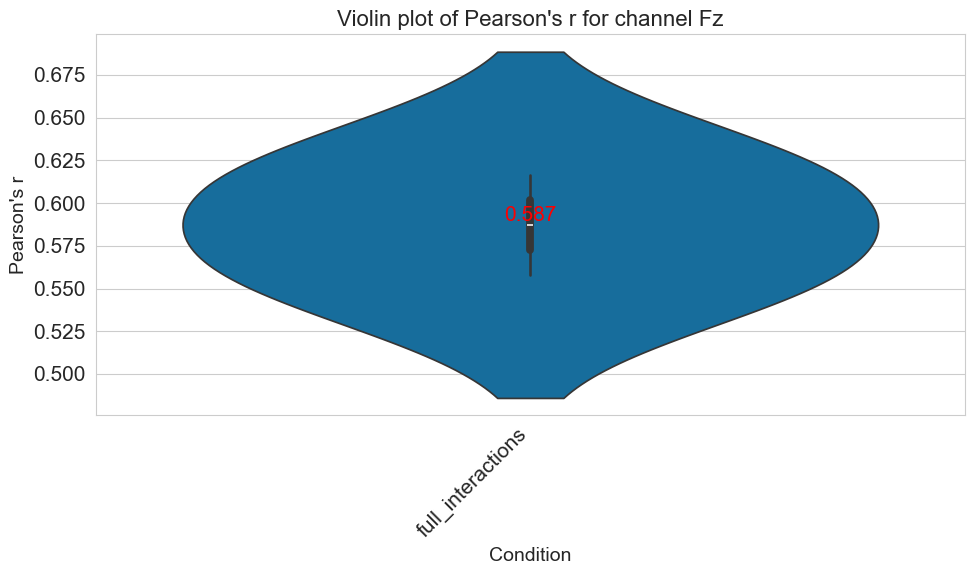

In [42]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    # for model_name, pearsons_r_results in person_results.items():
    #     data = pearsons_r_results[channel]['cv_pearsons_r']
    #     sns.violinplot(data, label=f"{model_name}: {np.mean(data):.3f}")
    # 
    # plt.legend()
    # Prepare the data for the DataFrame
    # Prepare the data for the DataFrame
    rows = []
    means = []
    for key, value in person_results.items():
        cv_values = value[channel]['cv_pearsons_r']
        rows.extend({'Condition': key, 'Pearson\'s r': val} for val in cv_values)
        means.append((key, sum(cv_values) / len(cv_values)))
    
    # Create DataFrame
    df = pd.DataFrame(rows)
    
    # Plot using seaborn
    plt.figure(figsize=(10, 6))
    ax = sns.violinplot(x='Condition', y='Pearson\'s r', data=df, palette='colorblind')
    
    # Annotate with means
    for i, (condition, mean) in enumerate(means):
        ax.text(i, mean, f"{mean:.3f}", color="red", ha="center", va="bottom", fontsize=15)
    
    # Plot aesthetics
    plt.title(f"Violin plot of Pearson's r for channel {channel}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Plot results - within people aggregations

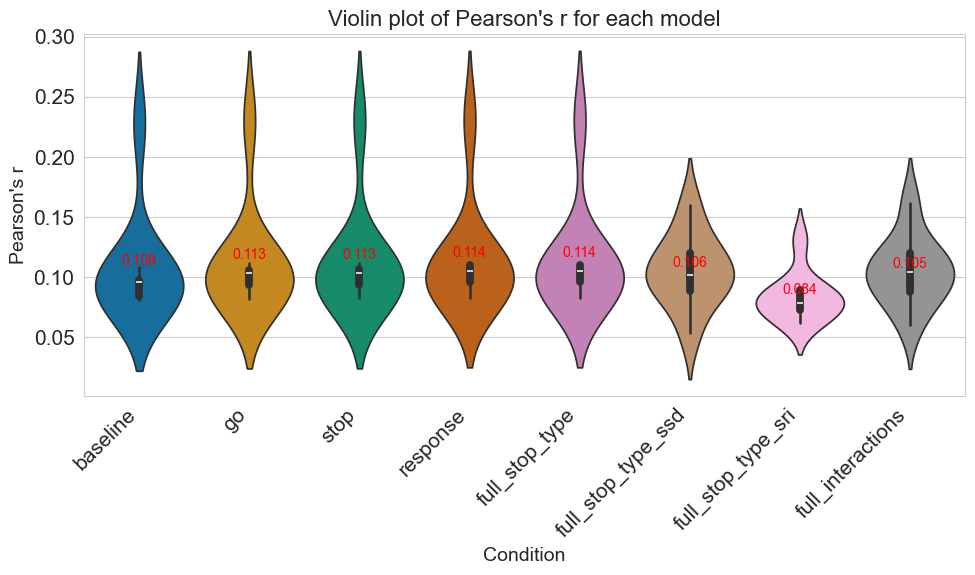

In [185]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Prepare the data for the DataFrame
rows = []
means = {}
for condition, values in person_model_agg.items():
    rows.extend({'Condition': condition, 'Pearson\'s r': val} for val in values)
    means[condition] = sum(values) / len(values)  # Calculate means for annotations

# Create DataFrame
df = pd.DataFrame(rows)

# Plot using seaborn
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='Condition', y='Pearson\'s r', data=df, palette='colorblind')

# Annotate means
for i, condition in enumerate(means):
    mean_value = means[condition]
    ax.text(i, mean_value, f"{mean_value:.3f}", color="red", ha="center", va="bottom", fontsize=10)

# Plot aesthetics
plt.title("Violin plot of Pearson's r for each model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

In [43]:
file_names = file_names[:6]
results_main_path = '../data/cv_ridge'

unfold_models = ['baseline', 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions']

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=False,
                crop=None
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

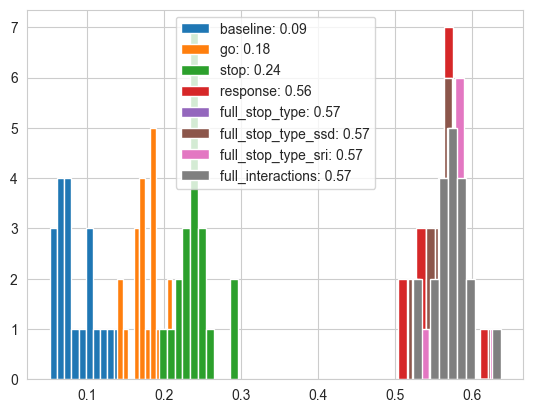

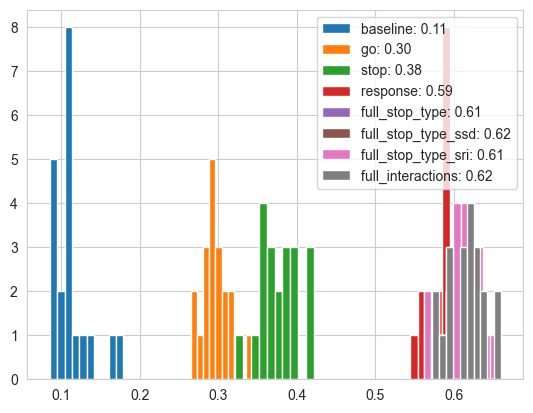

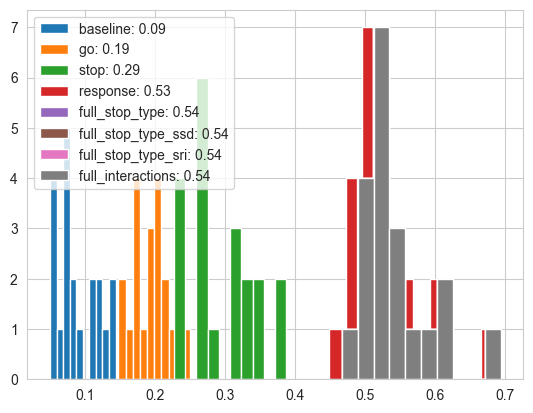

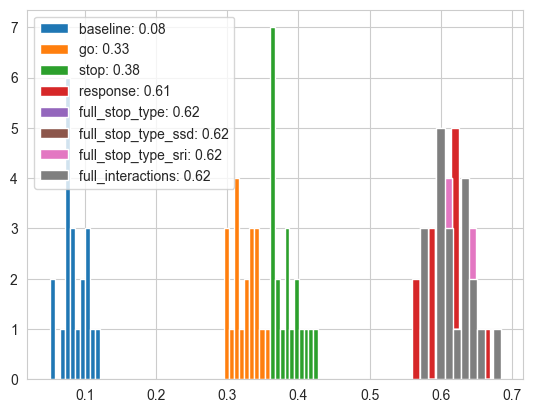

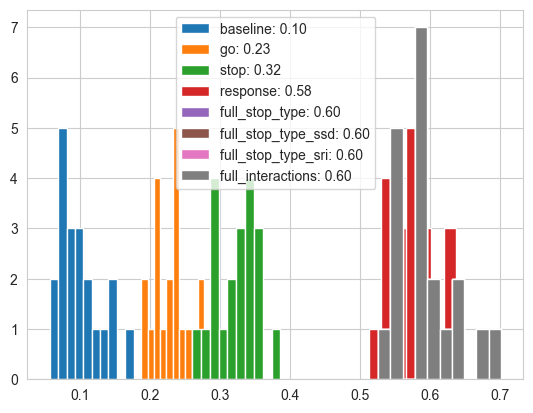

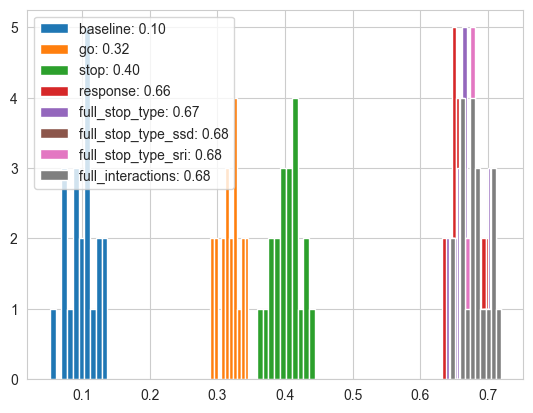

In [44]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.2f}")


    plt.legend()

Plot results - within people aggregations


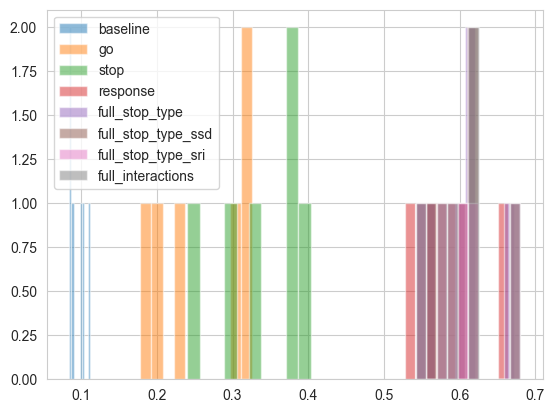

In [45]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()

In [ ]:
# def calculate_brain_score(
#         cv_results,
#         test=True,
#         crop=(0,0.5),
#         sfreq=64,
#         epoch_lim = (-0.2, 1.58),
# ):
#     if test:
#         variable = 'test'
#     else:
#         variable = 'train'
# 
#     person_results = {}
#     for channel in cv_results.keys():
#         test_original_cvs = cv_results[channel][f'{variable}_original'].to_numpy()
#         test_predicted_cvs = cv_results[channel][f'{variable}_predicted'].to_numpy()
# 
#         # epochs: -0.2 to 1.58 ms -> 0 to 114
#         if crop is None:
#             t_min, t_max = epoch_lim
#         else:
#             t_min, t_max = crop
# 
#         # calculate time window in timepoints
#         t_min_tp = int((t_min - epoch_lim[0])*sfreq)
#         t_max_tp = int((t_max - epoch_lim[0])*sfreq)
# 
#         # iterate over cv repeats
#         cv_pearsons_r = []
#         for i, (original, predicted) in enumerate(zip(test_original_cvs, test_predicted_cvs)):
#             original_cropped = np.array(original)[:, t_min_tp:t_max_tp]
#             predicted_cropped = np.array(predicted)[:, t_min_tp:t_max_tp]
# 
#             original_cropped_flatten = original_cropped.flatten()
#             predicted_cropped_flatten = predicted_cropped.flatten()
# 
#             # calculate pearsons r
#             r = np.corrcoef(original_cropped_flatten, predicted_cropped_flatten)[0, 1]
#             cv_pearsons_r.append(r)
# 
#         cv_pearsons_r = np.array(cv_pearsons_r)
#         r_mean = cv_pearsons_r.mean()
#         r_sd = cv_pearsons_r.std()
# 
#         person_results[channel] = {'cv_pearsons_r': cv_pearsons_r, 'cv_mean': r_mean, 'cv_std': r_sd}
# 
#     return person_results